In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from datetime import datetime
from kneed import KneeLocator
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import math

warnings.filterwarnings('ignore')

Let's load the data and show the data types to verify that we are working with numerical data

In [4]:
# Load the dataset
df = pd.read_csv('../clustering_dataset/merged_dataset_clean.csv')

In [5]:
df.dtypes

avg_token_per_clause    float64
duration_ms             float64
popularity                int64
swear_ratio             float64
syntactic_complexity    float64
flow_complexity         float64
percussiveness          float64
harmonic_richness       float64
trap_index              float64
boombap_index           float64
cloud_rap_index         float64
drill_index             float64
dtype: object

In [6]:
df.head()

,avg_token_per_clause,duration_ms,popularity,swear_ratio,syntactic_complexity,flow_complexity,percussiveness,harmonic_richness,trap_index,boombap_index,cloud_rap_index,drill_index
0,8.411765,194779.0,41,0.002331,827.027951,9.729363,436.723786,8243.404892,76.818564,6.09021,0.030088,436917.005814
1,11.018868,178080.0,50,0.003425,1235.714661,8.643912,767.217128,12318.142483,53.968604,4.80567,0.027996,327369.385881
2,9.349206,188534.0,27,0.015280,1257.959744,12.851980,390.861603,5333.853259,236.655557,8.04156,0.021039,520465.853309
3,7.474576,129560.0,26,0.000000,839.245747,10.268869,554.057106,8139.829804,30.773846,7.59162,0.029051,258665.914063
4,7.595745,167729.0,23,0.000000,579.992973,7.307106,218.716877,3882.840797,84.272900,10.29915,0.021726,732746.513668


## Normalizing data
In this step we normalize the dataset using the standard scaler so that all values are brought in the same range values

In [7]:
scaler = StandardScaler()
# apply scaling
X_scaled = scaler.fit_transform(df.values)
X_scaled

array([[ 1.06823081, -0.05729158,  0.35911434, ..., -1.01408119,
         1.45004168, -1.08387677],
       [ 2.84002481, -0.48604027,  0.82445083, ..., -1.41480086,
         1.17528943, -1.55245183],
       [ 1.70531855, -0.21763265, -0.36474242, ..., -0.40534628,
         0.26192173, -0.72650793],
       ...,
       [-1.84637235,  2.43886846, -0.98519107, ..., -0.66913921,
        -0.89426275,  2.02912001],
       [ 1.04324542,  1.0010622 , -0.88178296, ...,  0.1826498 ,
        -1.21530863,  1.27827358],
       [-1.23908648,  1.31763633, -0.51985458, ..., -1.44575935,
        -0.49822264,  0.42715427]], shape=(5016, 12))

## K-means execution
Now we run k means testing k values from 2 to 10, we store SSE and silhouette scores for each k tested so that we can analyze the results and try to find optimal or the best k values for our dataset.

In [8]:
k_range = range(2, 10)
sse_values = []
silhouette_scores = []

last_sse = 1

for k in k_range:
    print(f"Fitting k: {k}", end=" ")

    # run k means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # get SSE
    sse = kmeans.inertia_
    sse_values.append(sse)
    sse_delta = abs(((sse - last_sse) / last_sse) * 100)
    last_sse = sse
    
    # compute silhouette score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"SSE: {sse:.2f} - Silhouette Score: {silhouette_avg:.4f} - SSE delta: {sse_delta:.2f} %")


Fitting k: 2 SSE: 51467.26 - Silhouette Score: 0.1394 - SSE delta: 5146626.17 %
Fitting k: 3 SSE: 47373.22 - Silhouette Score: 0.1112 - SSE delta: 7.95 %
Fitting k: 4 SSE: 44859.72 - Silhouette Score: 0.1214 - SSE delta: 5.31 %
Fitting k: 5 SSE: 42640.52 - Silhouette Score: 0.1088 - SSE delta: 4.95 %
Fitting k: 6 SSE: 40477.04 - Silhouette Score: 0.1124 - SSE delta: 5.07 %
Fitting k: 7 SSE: 38958.57 - Silhouette Score: 0.1017 - SSE delta: 3.75 %
Fitting k: 8 SSE: 37771.61 - Silhouette Score: 0.1019 - SSE delta: 3.05 %
Fitting k: 9 SSE: 36743.66 - Silhouette Score: 0.0980 - SSE delta: 2.72 %


We are using the KneeLocator function to find the optimal K based on the elbow method, as SSE values are represented by a convex, decreasing curve, we set up KneeLocator with `curve='convex'` and `direction='decreasing'` to find the point of the biggest decrease

In [9]:
kneedle = KneeLocator(k_range, sse_values, curve='convex', direction='decreasing')
best_k = kneedle.elbow

print(f"Best K = {best_k}. Elbow method on SSE")

Best K = 6. Elbow method on SSE


## Visualization
Finally we can plot how SSE and silhouette score values for each k. On the silhouette score we plot a vertical line to represent the best K value found

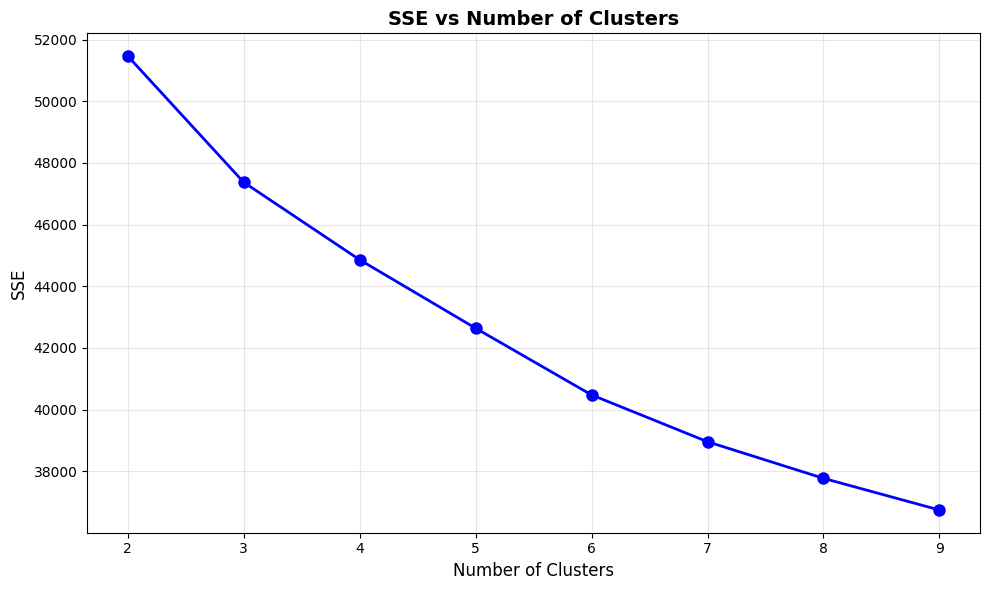

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('SSE', fontsize=12)
plt.title('SSE vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

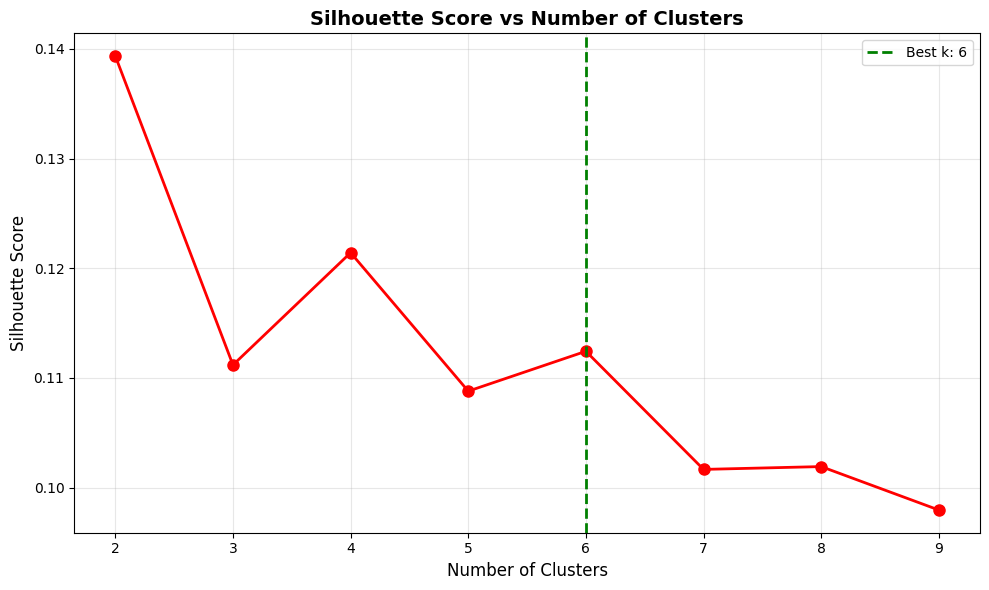

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='g', linestyle='--', linewidth=2, label=f'Best k: {best_k}')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [12]:
def k_means_run_analysis(num_clusters, num_pca_components):
    print(f"=========== Testing K-means with K = {num_clusters} ===========")
    kmeans_best = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    best_k_labels = kmeans_best.fit_predict(X_scaled)
    
    # plot pca componetns
    pca = PCA(n_components=num_pca_components)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_k_labels,
                                cmap='viridis', edgecolors='k')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    plt.title(f'K-means with k: {num_clusters}',
                        fontsize=14, fontweight='bold')
    
    # plot cluster sizes
    # cluster sizes
    plt.figure(figsize=(10, 6))
    cluster_counts = pd.Series(best_k_labels).value_counts().sort_index()
    plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black')
    plt.xlabel('Cluster Number', fontsize=12)
    plt.ylabel('Cluster Elements', fontsize=12)
    plt.title(f'Cluster Sizes k: {num_clusters}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    
    # box plot of features
    n_features = len(df.columns)
    n_cols = 4
    n_rows = (n_features + n_cols - 1) // n_cols

    fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes3 = axes3.flatten()
    
    df['cluster'] = best_k_labels
    # skip cluster column which is generated by k means
    feature_columns = [col for col in df.columns if col != 'cluster']

    for idx, column in enumerate(feature_columns):
        ax = axes3[idx]

        # Prepare data for boxplot
        data_by_cluster = [df[df['cluster'] == i][column].values
                        for i in range(num_clusters)]

        bp = ax.boxplot(data_by_cluster, labels=[f'C{i}' for i in range(num_clusters)],
                        patch_artist=True, showmeans=True)

        # Color the boxplots
        colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_title(column, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        
    plt.show()

=========== Testing K-means with K = 2 ===========


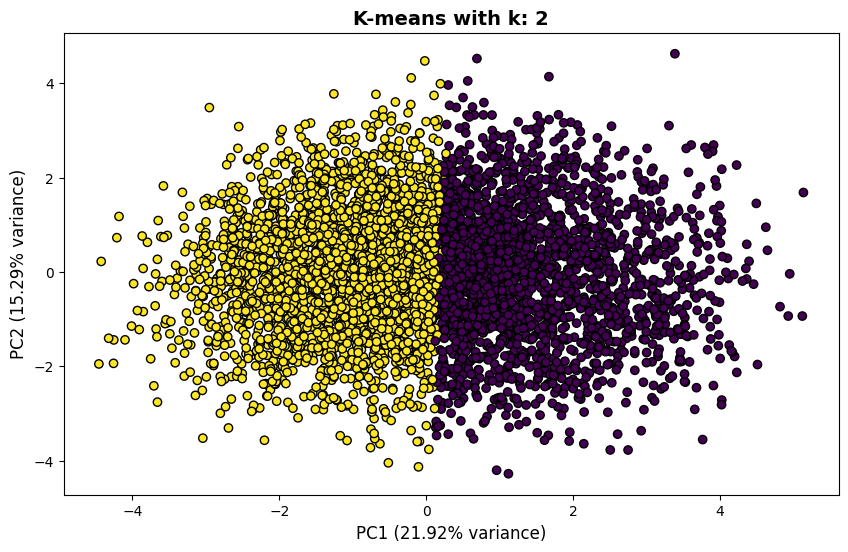

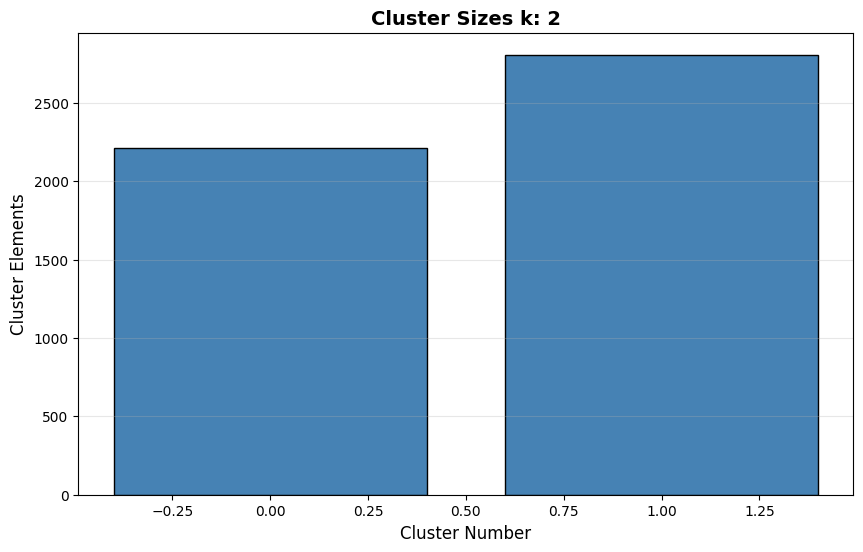

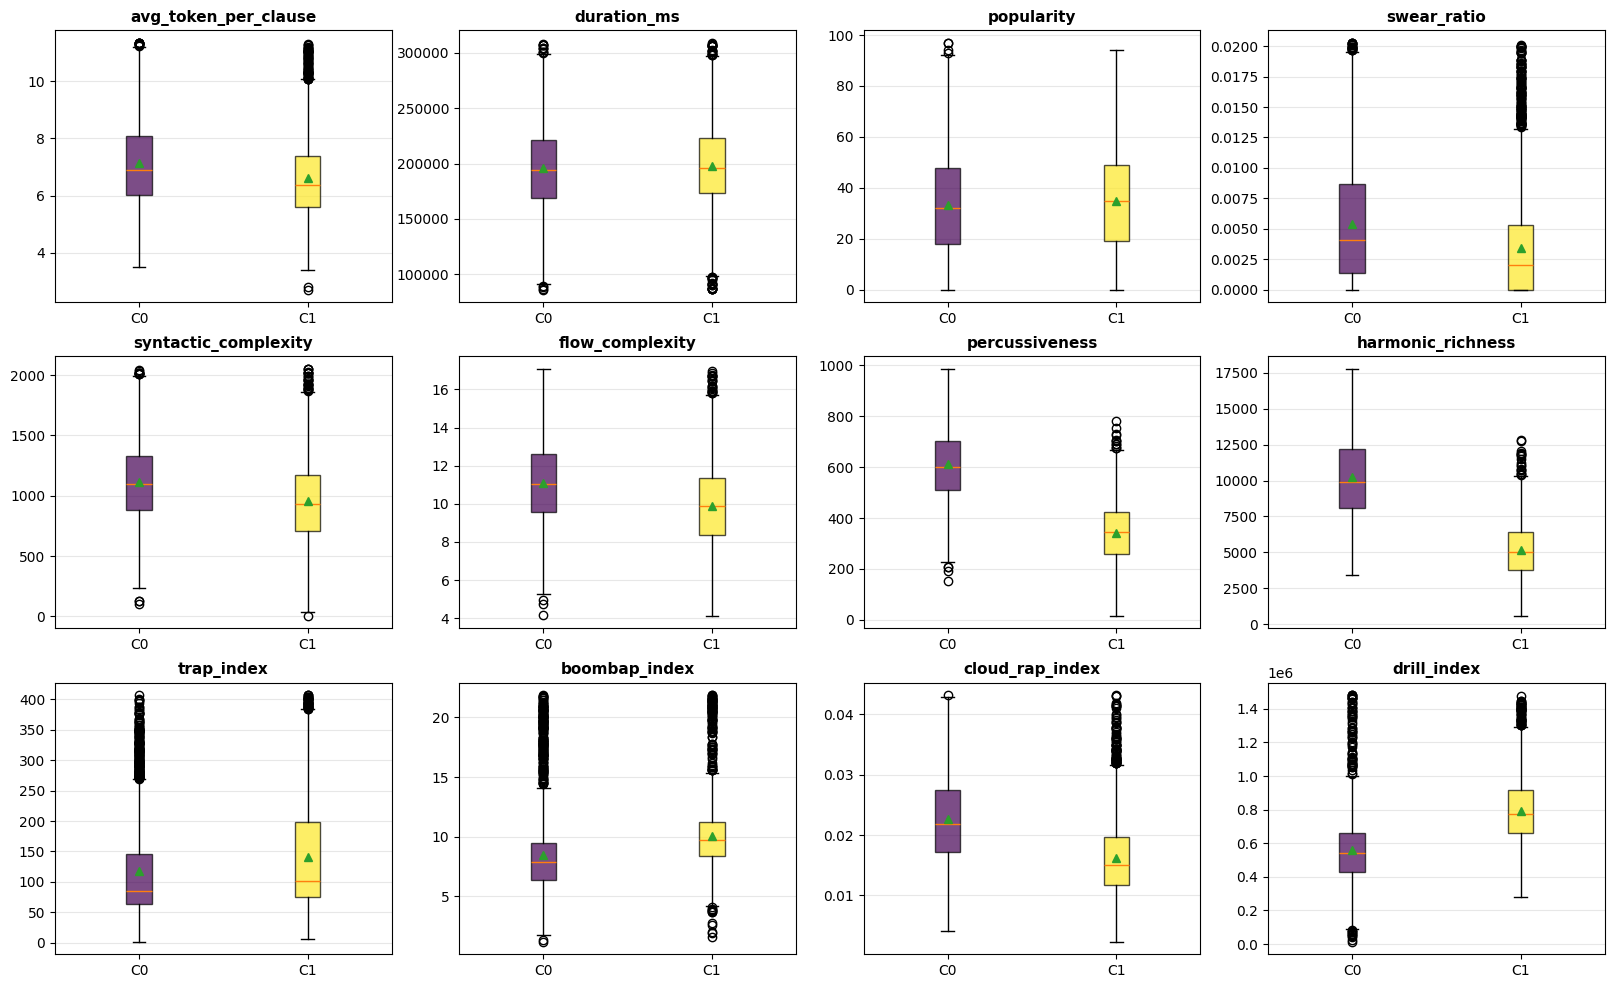

=========== Testing K-means with K = 4 ===========


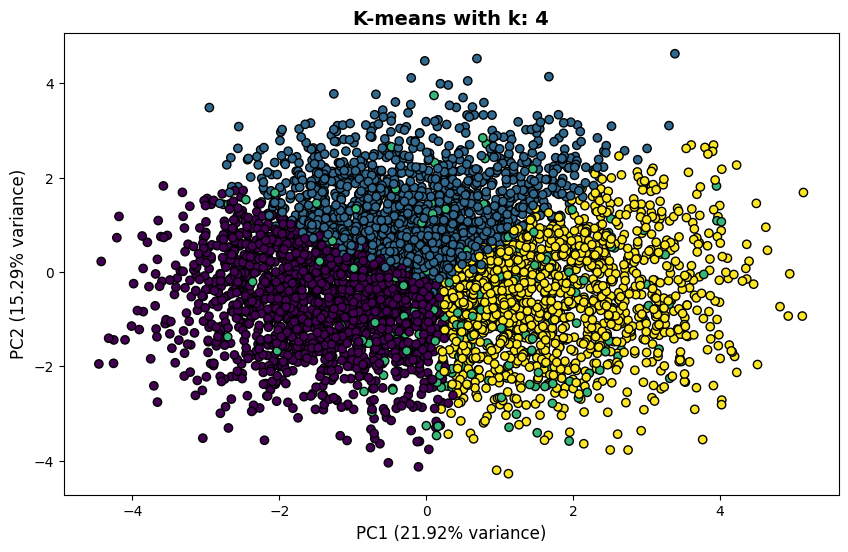

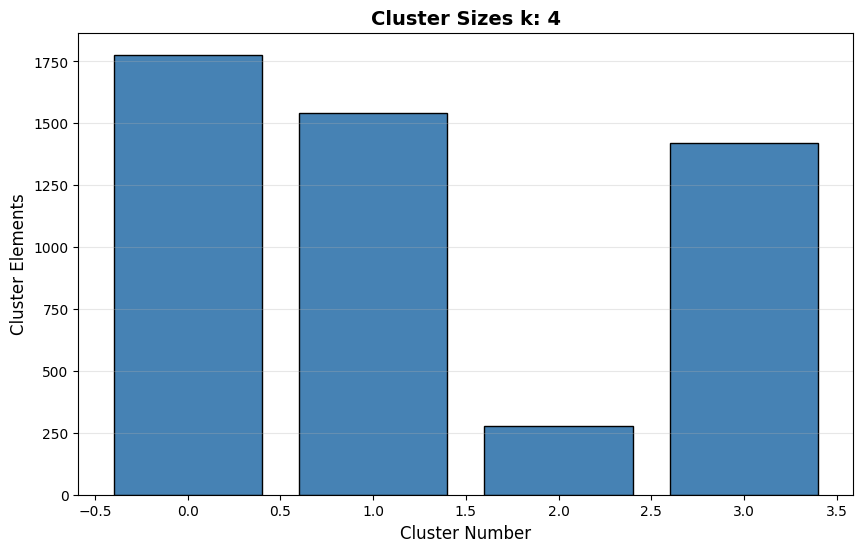

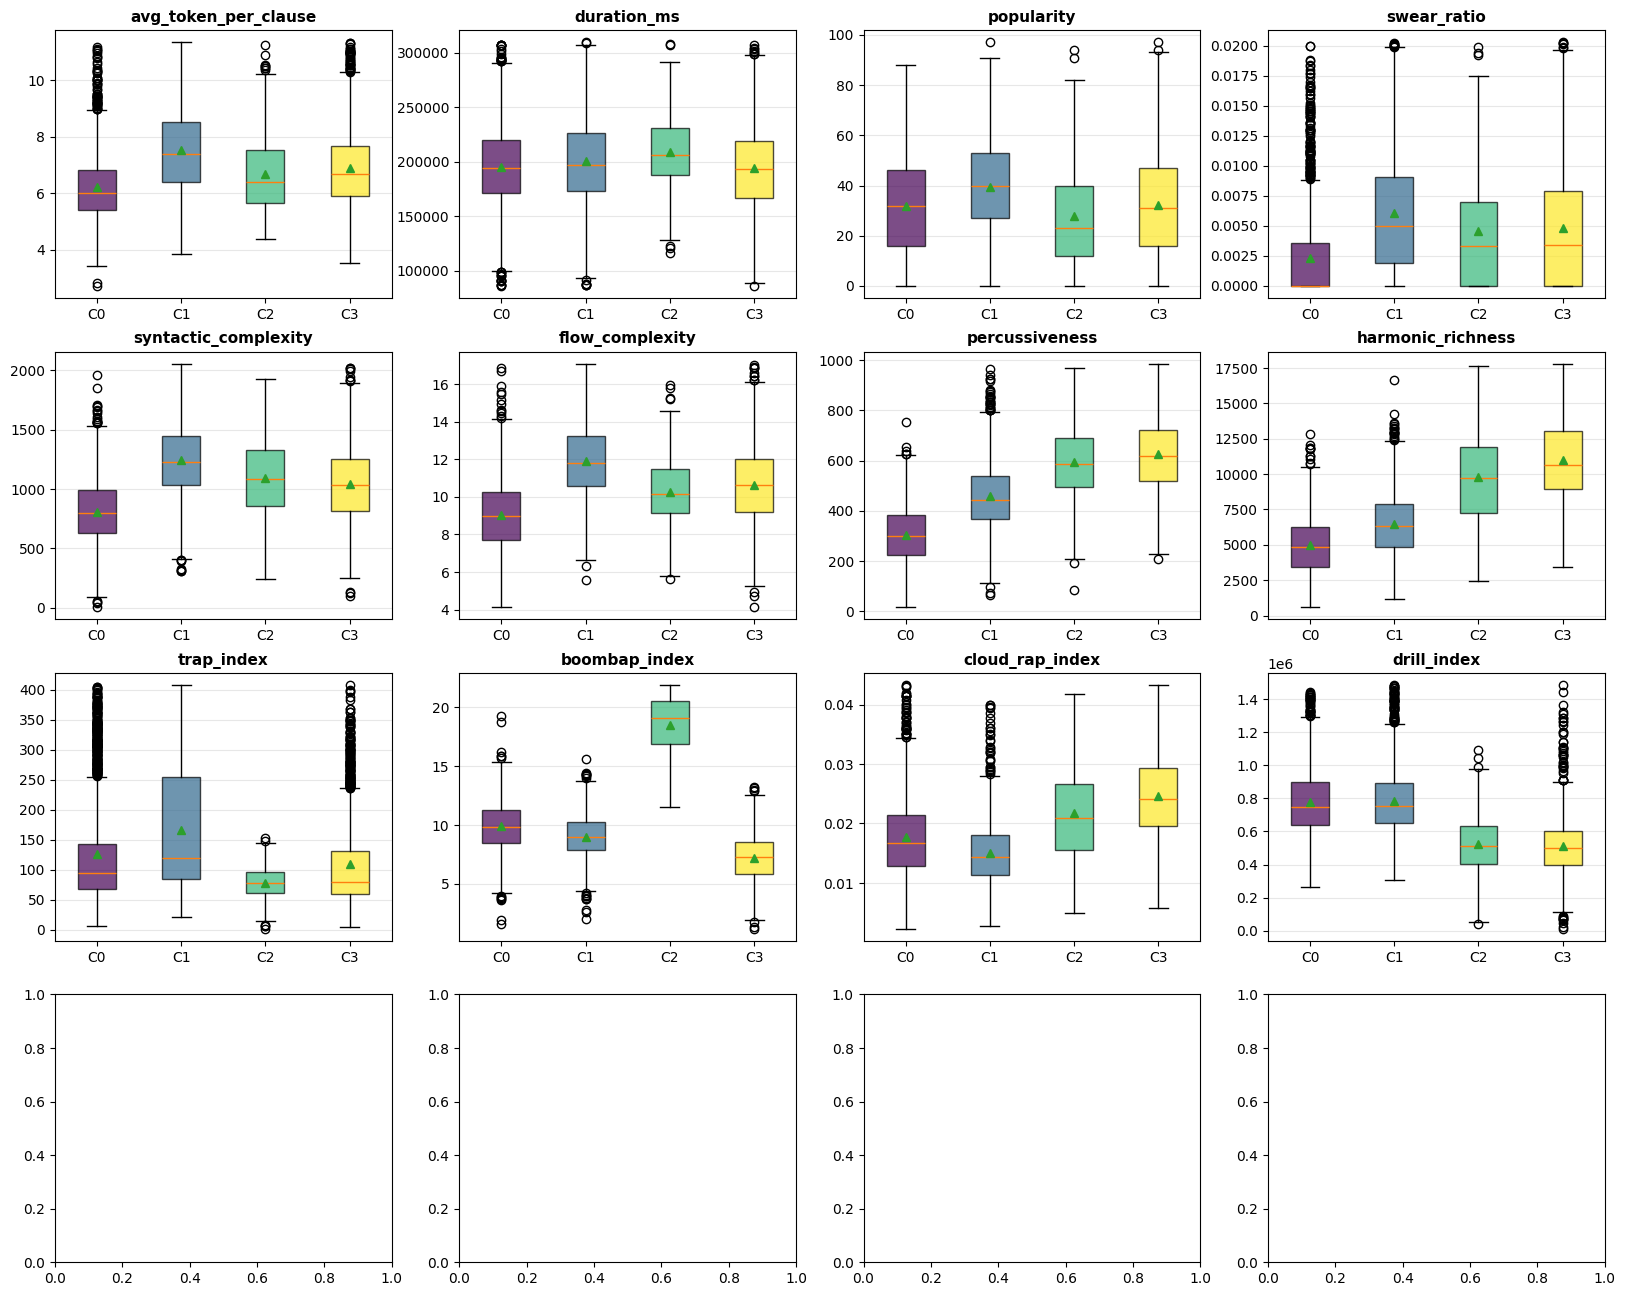

=========== Testing K-means with K = 6 ===========


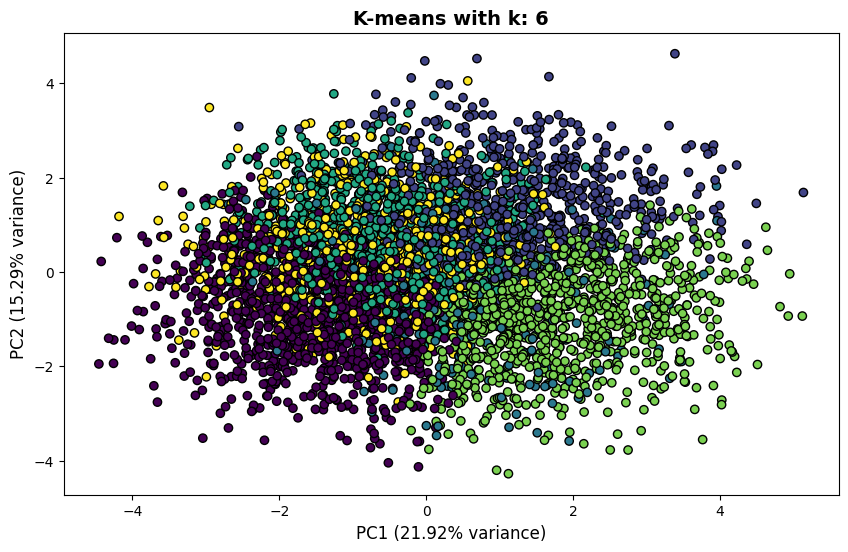

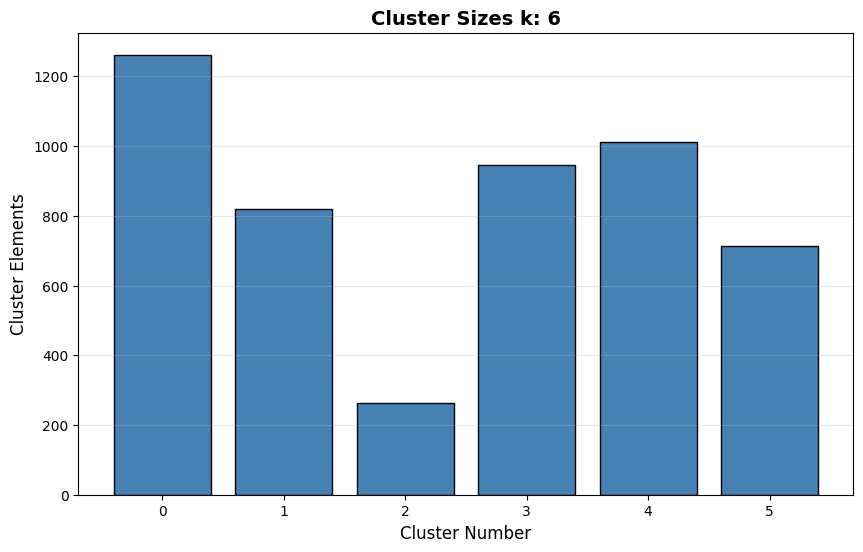

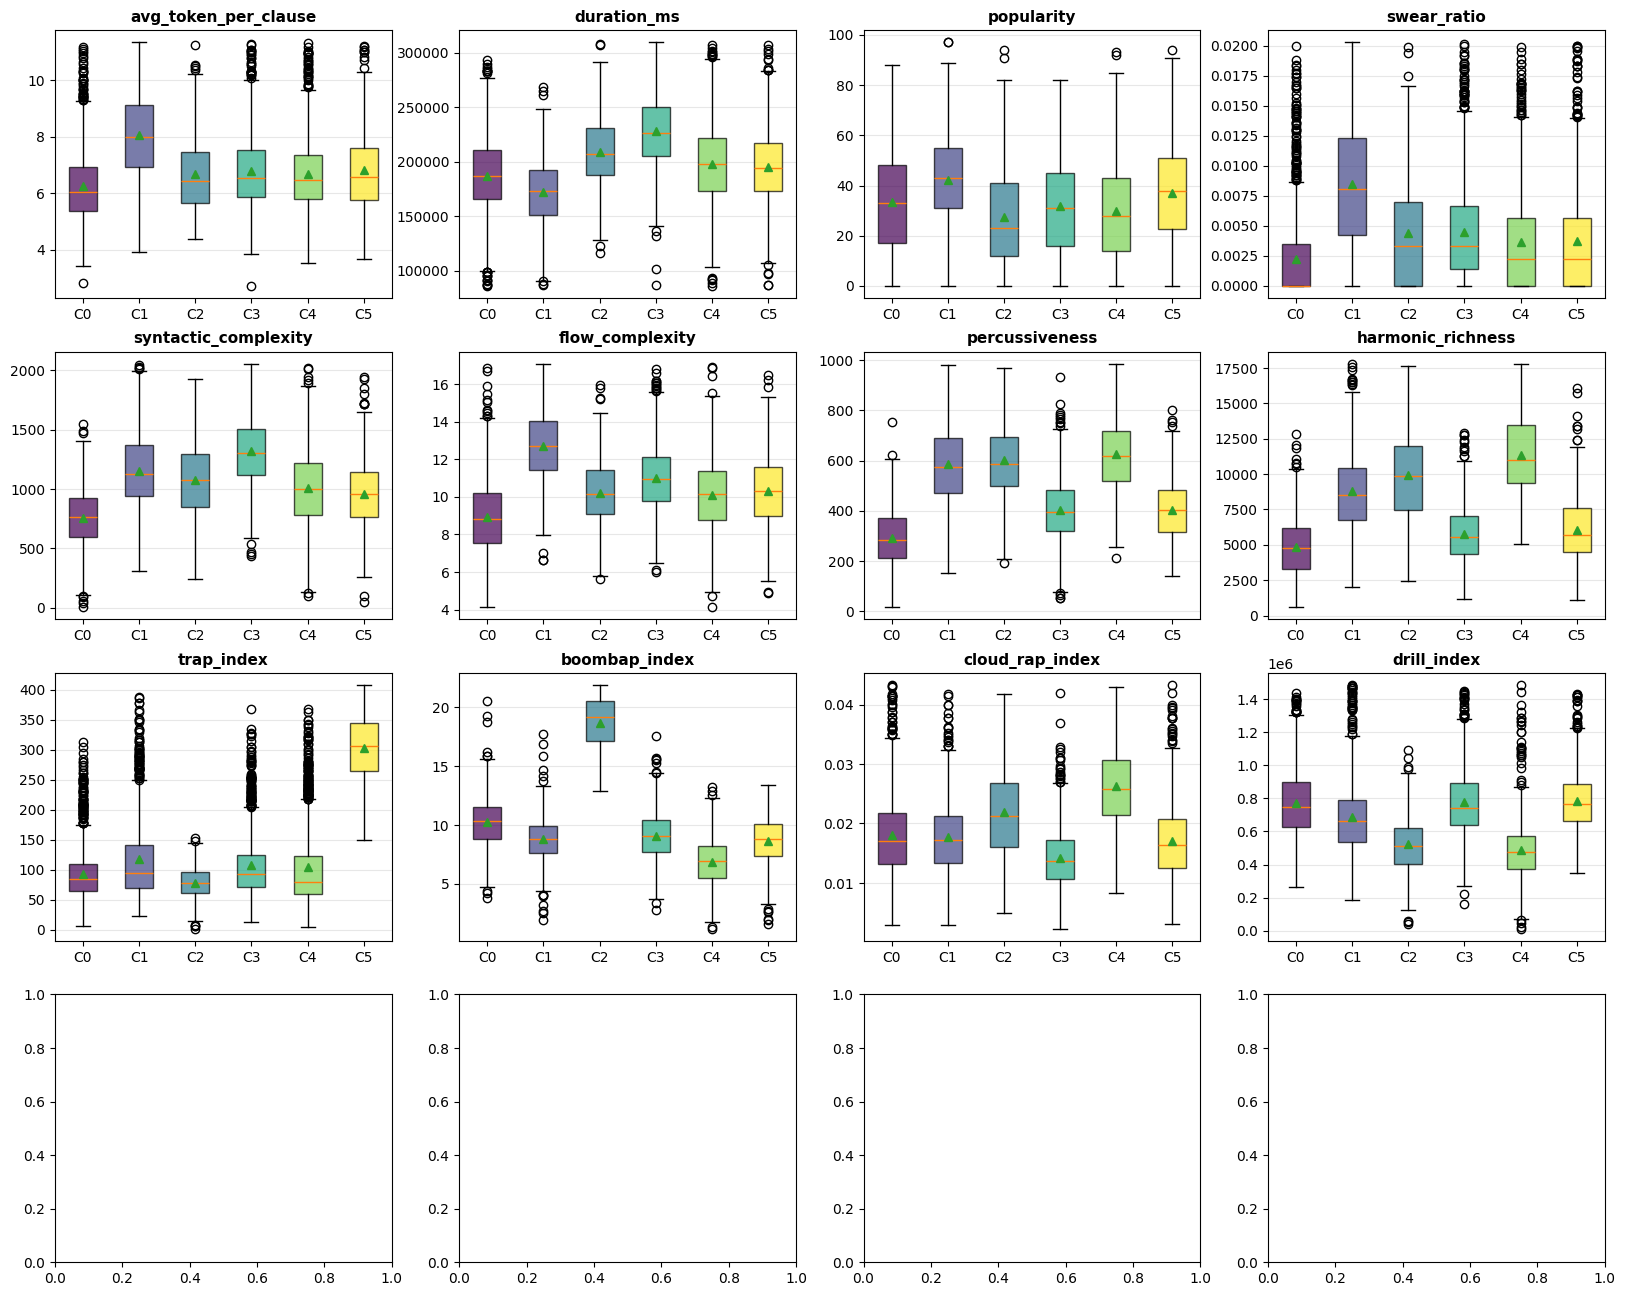

In [ ]:
k_to_test = [2, 3, 4, 5, 6]

for k in k_to_test:
    k_means_run_analysis(num_clusters=k, num_pca_components=2)

## t-SNE Visualization
t-SNE is a dimensionality reduction technique that is good at revealing clusters in high-dimensional space data

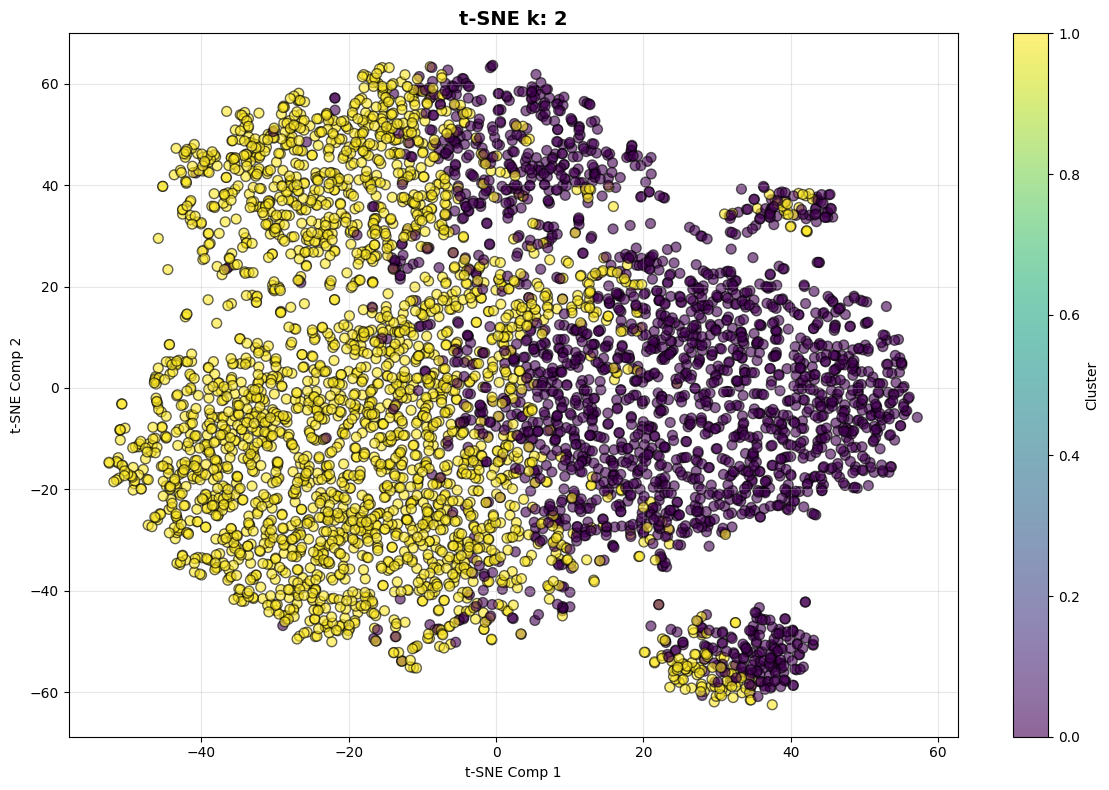

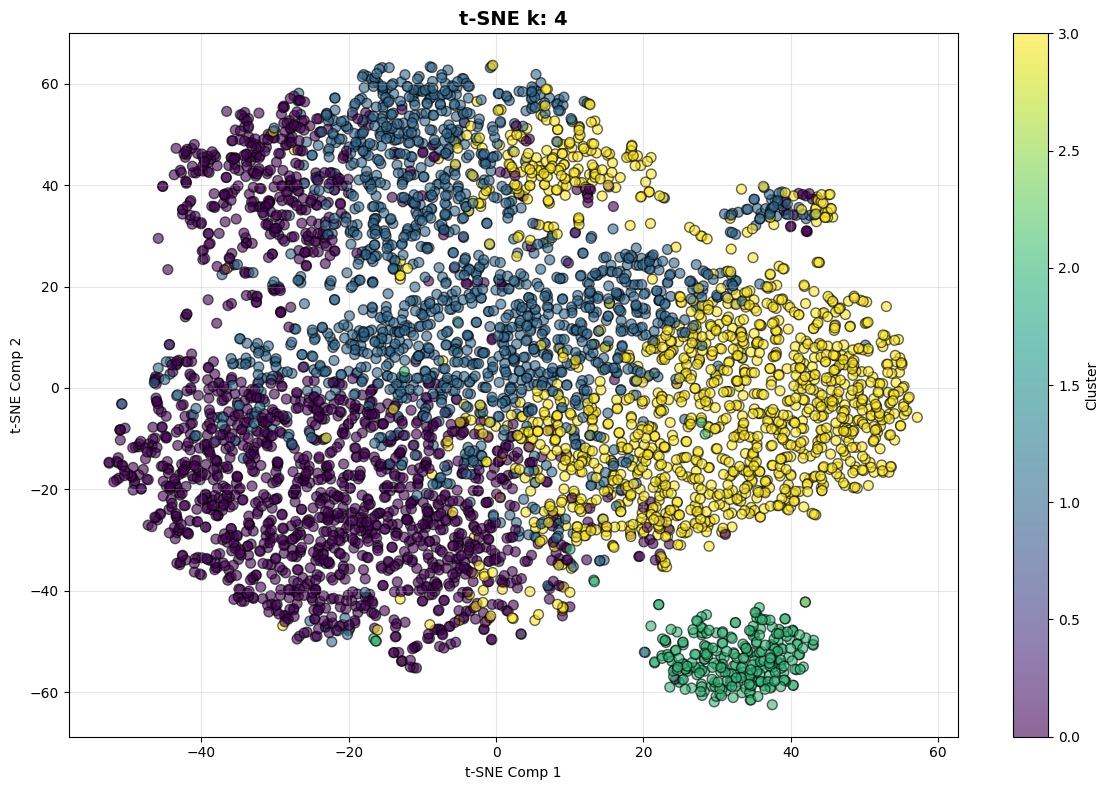

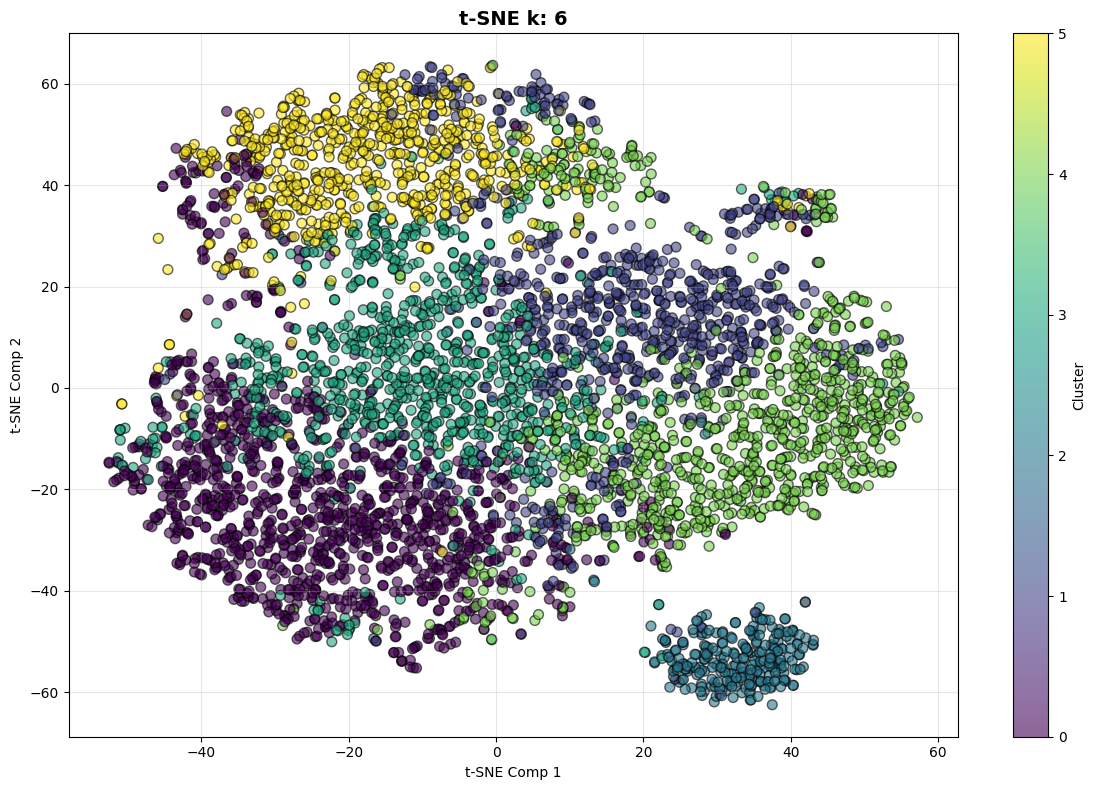

In [14]:
from sklearn.manifold import TSNE

def plot_tsne(num_clusters, perplexity=35, n_iter=1000):
    
    # cluster using k means
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # compute t sne
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=n_iter, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels,
                         cmap='viridis', edgecolors='k', alpha=0.6, s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('t-SNE Comp 1')
    plt.ylabel('t-SNE Comp 2')
    plt.title(f't-SNE k: {num_clusters}', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# compute t sne for all k values
for k in k_to_test:
    plot_tsne(num_clusters=k)

# Final cluster analysis

In the following section, we examine cluster characteristics and sizes, and visualize cluster profiles using a radar plot to identify discriminative features. The number of clusters was set to k = 4. A solution with k = 2 was too coarse, instead k = 4 exhibited clearer separation in both t-SNE and PCA projections. Even though the elbow method indicated k = 6, the k = 4 solution provided a better balance between separation and interpretability.

In [16]:
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

In [19]:
df['cluster'] = cluster_labels
df.head()

,avg_token_per_clause,duration_ms,popularity,swear_ratio,syntactic_complexity,flow_complexity,percussiveness,harmonic_richness,trap_index,boombap_index,cloud_rap_index,drill_index,cluster
0,8.411765,194779.0,41,0.002331,827.027951,9.729363,436.723786,8243.404892,76.818564,6.09021,0.030088,436917.005814,3
1,11.018868,178080.0,50,0.003425,1235.714661,8.643912,767.217128,12318.142483,53.968604,4.80567,0.027996,327369.385881,3
2,9.349206,188534.0,27,0.015280,1257.959744,12.851980,390.861603,5333.853259,236.655557,8.04156,0.021039,520465.853309,1
3,7.474576,129560.0,26,0.000000,839.245747,10.268869,554.057106,8139.829804,30.773846,7.59162,0.029051,258665.914063,3
4,7.595745,167729.0,23,0.000000,579.992973,7.307106,218.716877,3882.840797,84.272900,10.29915,0.021726,732746.513668,0


In [21]:
df.columns

Index(['avg_token_per_clause', 'duration_ms', 'popularity', 'swear_ratio',
       'syntactic_complexity', 'flow_complexity', 'percussiveness',
       'harmonic_richness', 'trap_index', 'boombap_index', 'cloud_rap_index',
       'drill_index', 'cluster'],
      dtype='object')

Below we want to get the cluster size for each cluster label to see the dimension of each cluster

In [33]:
num_cluster_components = df['cluster'].value_counts()
print(num_cluster_components)


cluster
0    1777
1    1543
3    1419
2     277
Name: count, dtype: int64


Finally we plot each cluster, using our chosen K with a radar plot. With a radar plot we can study the characteristics of each cluster so that we can interpret results in a global way, compared to boxplots which are too dispersive in feature representation. With radar plot we have all cluster features on a common axis and can describe the characteristics of each cluster.

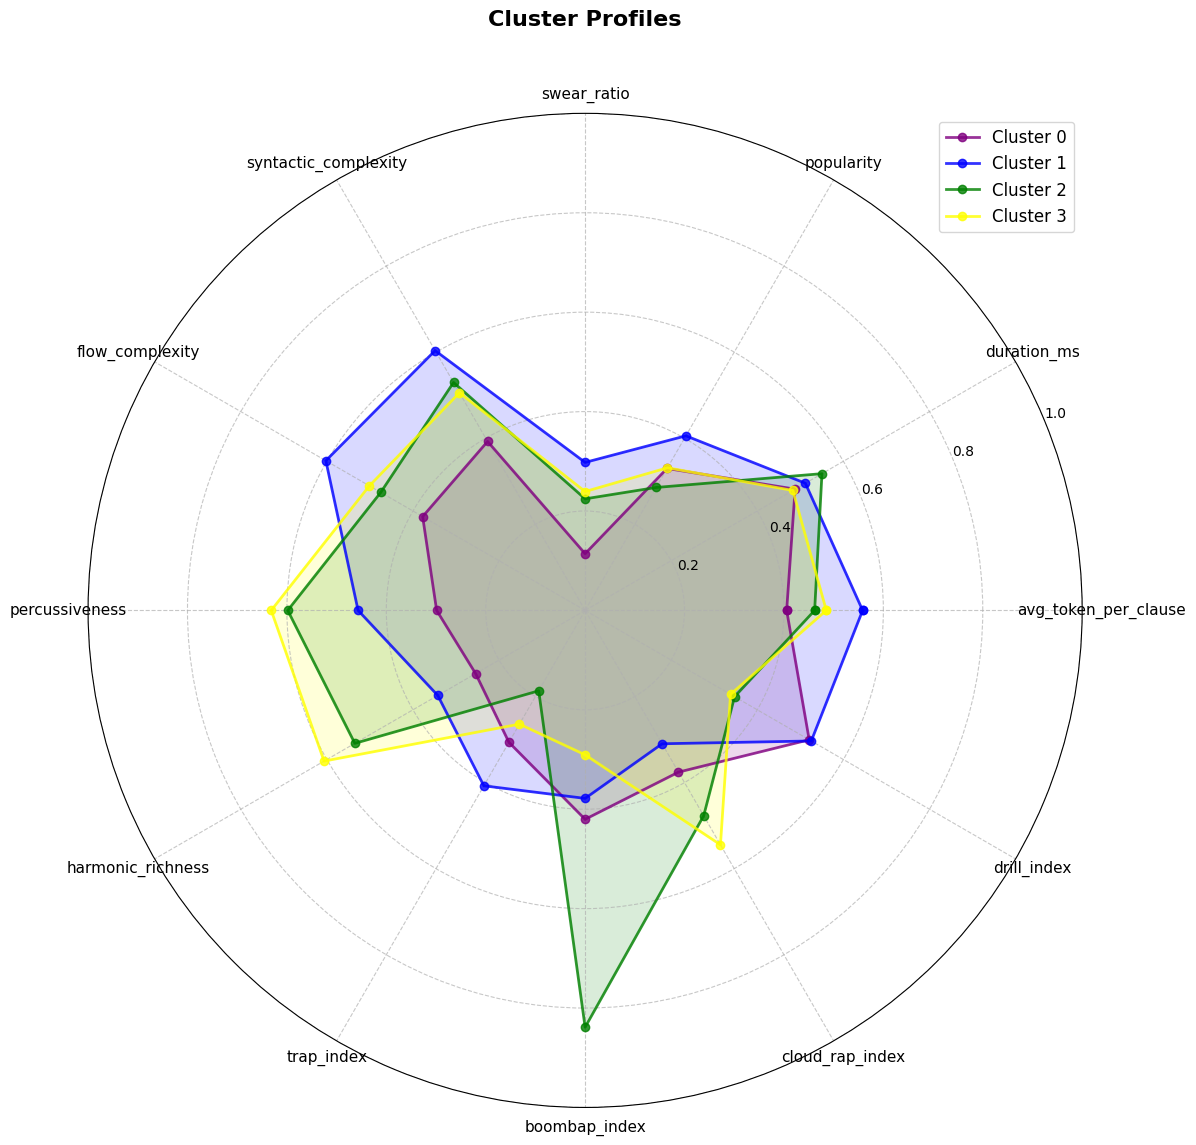

In [27]:
from math import pi

# Normalize features to 0-1 scale
normalized_df = (df[numeric_features] - df[numeric_features].min()) / (df[numeric_features].max() - df[numeric_features].min())

# get data for all clusters
cluster_data = {}
for cluster_id in sorted(df['cluster'].unique()):
    cluster_data[cluster_id] = normalized_df[df['cluster'] == cluster_id].mean()

N = len(numeric_features)

# angles for each cluster
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
colors = ['purple', 'blue', 'green', 'yellow']

# plot clusters
for idx, (cluster_id, data) in enumerate(cluster_data.items()):
    values = data.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, 
            label=f'Cluster {cluster_id}', 
            color=colors[idx], alpha=0.8)
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(numeric_features, size=11)
ax.set_ylim(0, 1)

ax.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)
plt.title('Cluster Profiles', size=16, y=1.08, fontweight='bold')

plt.tight_layout()
plt.show()